# **Final Model Configuration and Results**
**Train Accuracy:** 68%  
**Test Accuracy:** 63%  
**Train Accuracy (Last Char):** 70%++  
**Test Accuracy (Last Char):** 69%

Changes made:
- Model dimension ```d_model = 512```
- Attention heads ```n_heads = 8```
- Optimiser - AdamW with gradient clipping
- Learning rate schedule - Cosine Decay with Linear Warmup
- Learning rate ```lr = 1e-3```
- Batch size ```B = 256```
- Sequence length ```T = 64```

In [1]:
!git clone https://github.com/beckhamtoh/char-llm-assignment.git
%cd char-llm-assignment

Cloning into 'char-llm-assignment'...
remote: Enumerating objects: 160, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 160 (delta 75), reused 117 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (160/160), 31.91 MiB | 21.05 MiB/s, done.
Resolving deltas: 100% (75/75), done.
/kaggle/working/char-llm-assignment


In [2]:
# Enable autoreload of local Python modules (e.g., models)
# %load_ext autoreload
# %autoreload 2

# manual reload for local modules
import importlib

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from functools import partial
import numpy as np
import jax
import jax.numpy as jnp
import optax
import time

# local imports
import models.models as models
import util.generation as generation

In [4]:
# initialize the jax random key
key = jax.random.key(0)

INFO:2025-11-01 20:58:26,367:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-11-01 20:58:26,390:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


# Load data

In [5]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("./data/text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [6]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [7]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [8]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

ur one nine nine five astronaut norman thagard became the first american to ride to space on board a russian launch vehicle argu

nine one three two zero zero one michael ritchie american film director b one nine two zero two zero zero two ruth fertel americ

iver systems they run parallel to the himalaya mountains from jammu and kashmir in the west to assam in the east draining the st

ition of patronage in the civil service and the army and the third reform act which greatly extended democracy by giving the vot

ke lasithi omalos and nidha caves like diktaion and idaion cave and gorges like the famous gorge of samaria climate crete stradd



# Create a basic Transformer model

In [9]:
def create_train_state(rng, vocab_size=27, d_model=64, n_layers=6, n_heads=8, max_len=128):
    # create a basic Transformer model
    model = models.DecoderOnlyTransformer(vocab_size, d_model, n_layers, n_heads, max_len)
    # create a dummy input for initialization
    dummy = jnp.zeros((1, min(16, max_len)), dtype=jnp.int32)
    # pass the dummy input to the model to initialize the parameters
    params = model.init({"params": rng}, dummy)["params"]
    return model, params

In [10]:
# vocab size
vocab_size= len(char_set)

# internal model dimensions
d_model=512

# number of attention heads
n_heads=8

# number of Transformer layers
n_layers=4

# maximum sequence length
max_len=128

model, params = create_train_state(key, vocab_size, d_model, n_layers, n_heads, max_len)

In [11]:
# compute the number of parameters
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters: {count_params(params):_}")

Number of parameters: 12_695_552


In [12]:
# sanity check: create a batch of data & run a forward pass
B, T = 4, 32
batch = jax.random.randint(
    key=key,
    shape=(B, T), minval=0, maxval=len(char_set))
logits = model.apply({"params": params}, batch)

print("batch shape:", batch.shape)  # (B, T)
print("logits shape:", logits.shape)  # (B, T, vocab_size)

batch shape: (4, 32)
logits shape: (4, 32, 27)


# Loss function

In [ ]:
@partial(jax.jit, static_argnames=['last_token_only'])
def loss_and_metrics(logits, targets, label_smoothing=0.1, temperature=0.8, last_token_only=False):
    """
    Compute cross-entropy loss with label smoothing, temperature sharpening, and accuracy.

    Args:
        logits: (B, T, V) float array of unnormalized scores.
        targets: (B, T) integer array with ground-truth class ids.
        label_smoothing: float, amount of smoothing (0.0 = hard labels).
        temperature: float > 0, scales logits. <1 sharpens, >1 softens.
        last_token_only: bool, if True compute loss only on last token.

    Returns:
        loss: scalar average cross-entropy.
        metrics: dict with keys "loss", "acc", "acc_last".
    """
    vocab = logits.shape[-1]
    
    # Apply temperature sharpening
    scaled_logits = logits / temperature
    
    # Flatten for loss computation
    flat_logits = scaled_logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)
    
    # One-hot encoding with label smoothing
    one_hot_targets = jax.nn.one_hot(flat_targets, vocab)
    smooth_targets = one_hot_targets * (1 - label_smoothing) + label_smoothing / vocab
    
    # Per-position cross-entropy
    per_pos = optax.softmax_cross_entropy(flat_logits, smooth_targets)
    per_pos = per_pos.reshape(targets.shape)  # (B, T)
    
    # Conditional loss: last token or full sequence
    loss = jax.lax.cond(
        last_token_only,
        lambda x: x[:, -1].mean(),
        lambda x: x.mean(),
        per_pos
    )
    
    # Predictions and accuracy (based on scaled logits)
    preds = jnp.argmax(scaled_logits, axis=-1)
    is_match = preds == targets
    acc_all = jnp.mean(is_match.astype(jnp.float32))
    acc_last = jnp.mean(is_match[:, -1].astype(jnp.float32))
    
    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}

# Optimization step:

In [14]:
# create an update function
def train_step(params, opt_state, x, y, tx):
    """Single optimization step using optax optimizer.

    Args:
      params: pytree of model parameters.
      opt_state: optax optimizer state corresponding to `params`.
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
      tx: optax.GradientTransformation (already initialized).

    Returns:
      new_params: updated parameters after one gradient step.
      new_opt_state: updated optimizer state.
      metrics: dict of scalar metrics (loss, acc).
    """
    def loss_fn(params):
        logits = model.apply({"params": params}, x)
        loss, metrics = loss_and_metrics(logits, y)
        return loss, metrics

    # compute gradients (loss is scalar, metrics is auxiliary)
    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # optax update: compute parameter updates and new optimizer state
    updates, new_opt_state = tx.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, metrics

# jit: last argument should be static because it is an object
train_step = jax.jit(train_step, static_argnames=("tx",))

# Batch creation:

In [15]:
# create a batch from the training data
def get_batch(text_int, B, T):
    """Create a random batch of data from text_int.

    Args:
      text_int: 1D array of token ids.
      B: batch size (number of sequences).
      T: sequence length (number of tokens per sequence).

    Returns:
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
    """
    # choose random starting indices for each sequence in the batch
    ix = np.random.randint(0, len(text_int) - T, size=B)
    # inputs are text from i to i+T
    x = np.stack([text_int[i:i+T] for i in ix])
    # targets are text from i+1 to i+T+1
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

## **Final Model Full Training Run**
AdamW Optimiser Creation  
Cosine Decay with Linear Warmup Learning Rate Schedule  

In [ ]:
# ---- CONFIG ----
niter = 100_000
B, T = 256, 64           # changed batch size 128 --> 256
B_test, T_test = 1024, 32

base_lr = 1e-3           # pick your base LR here
warmup_frac = 0.1
weight_decay = 1e-4

# ---- COSINE WARMUP + DECAY SCHEDULE ----
warmup_steps = int(warmup_frac * niter)
decay_steps  = niter - warmup_steps

def make_full_cosine(base_lr):
    def schedule(step):
        s = jnp.minimum(step, 1_000_000)
        warmup_lr = base_lr * (s / warmup_steps)
        cosine_decay = 0.5 * (1 + jnp.cos(jnp.pi * (s - warmup_steps) / decay_steps))
        cosine_lr = base_lr * cosine_decay
        return jnp.where(s < warmup_steps, warmup_lr, cosine_lr)
    return schedule

schedule_fn = make_full_cosine(base_lr)

# ---- OPTIMIZER ----
tx = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=schedule_fn, weight_decay=weight_decay)
)
opt_state = tx.init(params)

# ---- TRAINING LOOP ----
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
lr_history = []

time_start = time.time()

for it in range(niter):
    # --- training step ---
    input, target = get_batch(train_text_int, B, T)
    params, opt_state, metrics = train_step(params, opt_state, input, target, tx)

    loss = float(metrics['loss'])
    acc = float(metrics['acc'])
    acc_last = float(metrics['acc_last'])

    loss_history.append(loss)
    time_history.append(time.time() - time_start)

    # --- record and store current learning rate ---
    current_lr = float(schedule_fn(it))
    lr_history.append(current_lr)

    # --- periodic test ---
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start

        test_input, test_target = get_batch(test_text_int, B_test, T_test)
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)

        test_acc = float(test_metrics['acc'])
        test_acc_last = float(test_metrics['acc_last'])
        loss_test_history.append(float(test_loss))
        time_test_history.append(time_since_start)

        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print(f"\t \t learning rate: {current_lr:.6f}")
        print()


iteration 0  time: 10.3 seconds
	 	 loss(train :: test): 3.6527 :: 3.6802
	 	 accuracy (train :: test): 4.0% :: 3.8%
	 	 accuracy (last character) (train :: test): 4.7% :: 3.9%
	 	 learning rate: 0.000000

iteration 2_000  time: 823.0 seconds
	 	 loss(train :: test): 1.4761 :: 1.4977
	 	 accuracy (train :: test): 54.2% :: 53.9%
	 	 accuracy (last character) (train :: test): 50.8% :: 56.8%
	 	 learning rate: 0.000200

iteration 4_000  time: 1638.3 seconds
	 	 loss(train :: test): 1.3365 :: 1.4007
	 	 accuracy (train :: test): 58.1% :: 56.4%
	 	 accuracy (last character) (train :: test): 60.5% :: 61.5%
	 	 learning rate: 0.000400

iteration 6_000  time: 2449.8 seconds
	 	 loss(train :: test): 1.2629 :: 1.3496
	 	 accuracy (train :: test): 60.3% :: 57.5%
	 	 accuracy (last character) (train :: test): 68.0% :: 58.3%
	 	 learning rate: 0.000600

iteration 8_000  time: 3264.2 seconds
	 	 loss(train :: test): 1.2914 :: 1.3014
	 	 accuracy (train :: test): 59.6% :: 58.8%
	 	 accuracy (last cha

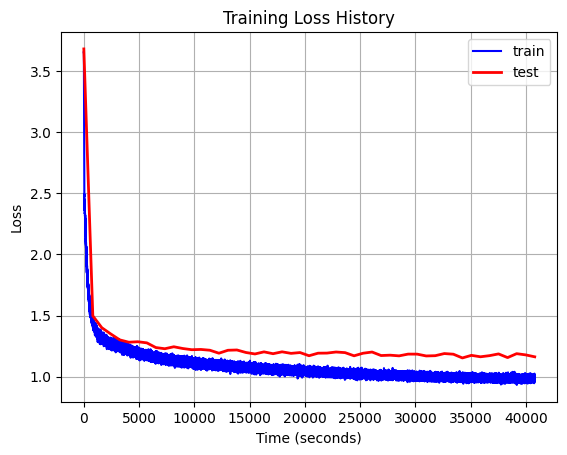

In [19]:
# plot the loss history
import matplotlib.pyplot as plt
plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

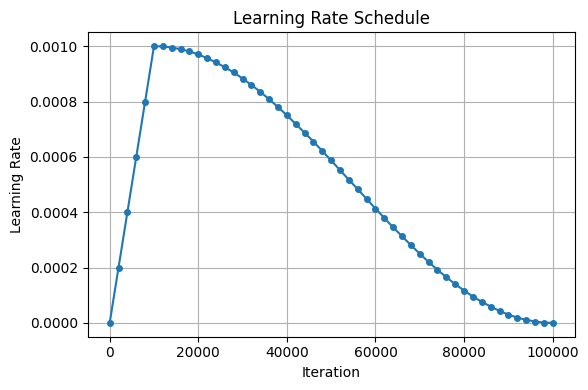

In [ ]:
# plot the learning rate schedule
import matplotlib.pyplot as plt
# --- build x-axis (iterations) ---
iters = list(range(niter))

# --- plot ---
plt.figure(figsize=(6,4))
plt.plot(iters, lr_history, linewidth=2)
plt.title("Learning Rate Schedule (Cosine Decay + Warmup)", fontsize=12)
plt.xlabel("Iteration", fontsize=11)
plt.ylabel("Learning Rate", fontsize=11)
plt.grid(True, linewidth=0.4, alpha=0.7)
plt.tight_layout()
plt.show()


In [20]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
# prompt_int = encode(prompt.lower())
prompt_int = jnp.array([ [char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generation.generate_tokens(model, params, rng, prompt_int, gen_len, block_size=64,
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 1000)
generated text:
hello my friend she is also the holy spirit in the ancient roman christianity chapter two one one zero of the paramount church and its associated guerilla groups is a small number of cruisers who have stood upon the territory three of the major regional defense systems agency since the one nine nine zero s music has been considered the subject of some distinctions between the parties and the party is walking to the party at a common liberal party in the case of the bears dimant this would not have the following changes the tides and the rest of the population is composed of sugar three petroleum products and services six zero zero zero zero two zero zero three est permanent pastures two four forests and woodland two four four other one zero one nine nine eight electricity consumption six seven two zero zero zero est population below poverty line na household income or consumption by percentage share lowest one zero na highest one zero na i